## Basic trip moving cargo
In this notebook, we set up a basic simulation where a vessel moves over a 1D network path. Next to just sailing from origin to destination the vessel now also collects cargo from the origin, and transports it to the destination. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd

# package(s) needed for plotting
import matplotlib.pyplot as plt
import plotly.express as px

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.HasContainer, # allows the object to contain cargo
    ), 
    {}
)

In [3]:
# make your preferred Node class out of available mix-ins.
Node = type(
    "Node", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID, 
        opentnsim.core.Locatable,    # allows the object to have a location
        opentnsim.core.HasContainer, # allows the object to contain cargo
    ),
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. This case we create a single edge of 100 km exactly.

In [4]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [5]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other three points 100 km apart to form a square
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000) # East from point 1

# define nodes with their geographic coordinates
node_info = {
    "0": {'position': (lon0, lat0), 'capacity': 100, 'level': 100},
    "1": {'position': (lon1, lat1), 'capacity': 100, 'level': 0},
}

In [6]:
# create list of edges
edges = [("0", "1"), ("1", "0")] # bi-directional edge

In [7]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, node in node_info.items():
    FG.add_node(name, geometry=Point(node['position'][0], node['position'][1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

In [8]:
# extract positions for plotting
positions = {node: (FG.nodes[node]["geometry"].x, FG.nodes[node]["geometry"].y) for node in FG.nodes}

# collect node labels
labels = {node: node for node in FG.nodes}

# compute edge labels as geodesic distances
edge_labels = {}
for u, v in FG.edges():
    lon1, lat1 = positions[u]
    lon2, lat2 = positions[v]
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    edge_labels[(u, v)] = f"{int(dist)} m"

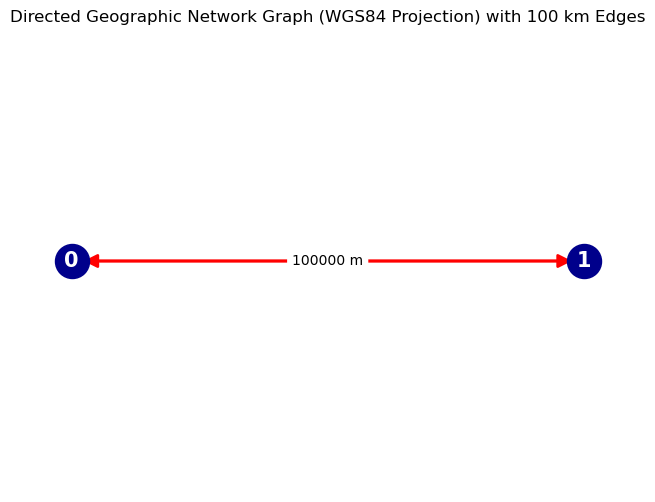

In [9]:
# Plot the graph
plt.figure(figsize=(8, 6))
nx.draw_networkx_edges(FG, pos=positions, width=2, edge_color="red", arrows=True, arrowsize=20)
nx.draw_networkx_nodes(FG, pos=positions, node_color="darkblue", node_size=600)
nx.draw_networkx_labels(FG, pos=positions, labels=labels, font_size=15, font_weight="bold", font_color="white")
nx.draw_networkx_edge_labels(FG, pos=positions, edge_labels=edge_labels, font_color="black", font_size=10)

plt.title("Directed Geographic Network Graph (WGS84 Projection) with 100 km Edges")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("off")
plt.grid(False)
plt.show()

#### 3. Run simulation

In [10]:
def calculate_distance(orig, dest):
    """method to calculate the greater circle distance in meters from WGS84 lon, lat coordinates"""
    
    wgs84 = pyproj.Geod(ellps='WGS84')
    distance = wgs84.inv(orig.x, orig.y, 
                         dest.x, dest.y)[2]
    
    return distance

In [11]:
def calculate_distance_along_path(FG, path):
    """method to calculate the greater circle distance along path in meters from WGS84 lon, lat coordinates"""

    distance_path = 0

    for node in enumerate(path[:-1]):
        orig = nx.get_node_attributes(FG, "geometry")[path[node[0]]]
        dest = nx.get_node_attributes(FG, "geometry")[path[node[0]+1]]
        distance_path += calculate_distance(orig, dest)

        if node[0] + 2 == len(path):
                    break

    return distance_path

In [12]:
def mission(env, vessel):
    """method that defines the simulation (load - move - unload - move)"""

    # *** load ***
    current_node = '0'
    amount = vessel.container.capacity
    duration = amount * 1000
    
    vessel.log_entry_v0(
                "Loading from node {} start".format(current_node),
                vessel.env.now, 0, env.graph.nodes[current_node]['geometry'])
    
    yield env.graph.nodes['0']['site'].container.get(amount)
    yield vessel.container.put(amount)
    yield env.timeout(duration)

    vessel.log_entry_v0(
                "Loading from node {} stop".format(current_node),
                vessel.env.now, 0, env.graph.nodes[current_node]['geometry'])
        
    # *** move ***
    route = nx.dijkstra_path(env.graph, "0", "1")
    vessel.route = route
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(FG, "geometry")[vessel.route[-1]]:
            break    

    # *** unload ***
    current_node = '1'
    amount = vessel.container.capacity
    duration = amount * 1000

    vessel.log_entry_v0(
                "Unloading to node {} start".format(current_node),
                vessel.env.now, 0, env.graph.nodes[current_node]['geometry'])

    yield vessel.container.get(amount)
    yield env.graph.nodes['1']['site'].container.put(amount)
    yield env.timeout(duration)
    
    vessel.log_entry_v0(
                "Unloading to node {} stop".format(current_node),
                vessel.env.now, 0, env.graph.nodes[current_node]['geometry'])
    
    # *** move ***
    vessel.route = nx.dijkstra_path(env.graph, "1", "0")    
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(FG, "geometry")[vessel.route[-1]]:
            break

In [13]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# create sites from dict  
nodes = []
for name, node in node_info.items():
    data_node = {
        "env": env,
        "name": name,
        "geometry": Point(node['position'][0], node['position'][1]),  # Point(longitude, latitude)
        "capacity": node['capacity'],
        "level": node['level'],
    }
    nodes.append(Node(**data_node))
    
# add sites to graph
for node in nodes:
    FG.add_node(node.name, geometry=node.geometry, site=node)
    # node.env = env
    # FG.nodes[node.name]['site'] = node

# add graph to environment
env.graph = FG

# create vessel from dict 
data_vessel = {
    "env": env,                                   # needed for simpy simulation, left empty for now
    "name": "Vessel",                             # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'], # required by Locatable, left empty for now
    "route": None,                                # required by Routeable, left empty for now
    "v": 1,                                       # required by Movable, 1 m/s to check if the distance is covered in the expected time
    "capacity": 10,                               # required by HasContainer
    "level": 0,                                   # required by HasContainer
}  
vessel = Vessel(**data_vessel)

# start the simulation
env.process(mission(env, vessel))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [14]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

'Vessel' logbook data:



,Message,Timestamp,Value,Geometry
0,Loading from node 0 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Loading from node 0 stop,2024-01-01 02:46:40,0,POINT (0 0)
2,Sailing from node 0 to node 1 start,2024-01-01 02:46:40,0,POINT (0 0)
3,Sailing from node 0 to node 1 stop,2024-01-02 06:33:20,0,POINT (0.8983152841195217 0)
4,Unloading to node 1 start,2024-01-02 06:33:20,0,POINT (0.8983152841195217 0)
5,Unloading to node 1 stop,2024-01-02 09:20:00,0,POINT (0.8983152841195217 0)
6,Sailing from node 1 to node 0 start,2024-01-02 09:20:00,0,POINT (0.8983152841195217 0)
7,Sailing from node 1 to node 0 stop,2024-01-03 13:06:40,0,POINT (0 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [15]:
# create eventtable from logs
def logbook2eventtable(objs):
    """ objs is a list of objects that has logbook as a property """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = calculate_distance(start_location, stop_location)
            
            events.append({
                'object name': obj.name,
                'activity name': activity,
                'start time': start_time,
                'stop time': stop_time,
                'start location': start_location,
                'stop location': stop_location,
                'duration (s)': duration_seconds,
                'distance (m)': distance_meters
            })
        
    # Final DataFrame
    eventtable = pd.DataFrame(events)
    return eventtable


In [16]:
eventtable = logbook2eventtable([vessel])
eventtable

,object name,activity name,start time,stop time,start location,stop location,duration (s),distance (m)
0,Vessel,Loading from node 0,2024-01-01 00:00:00,2024-01-01 02:46:40,POINT (0 0),POINT (0 0),10000.0,0.0
1,Vessel,Sailing from node 0 to node 1,2024-01-01 02:46:40,2024-01-02 06:33:20,POINT (0 0),POINT (0.8983152841195217 0),100000.0,100000.0
2,Vessel,Unloading to node 1,2024-01-02 06:33:20,2024-01-02 09:20:00,POINT (0.8983152841195217 0),POINT (0.8983152841195217 0),10000.0,0.0
3,Vessel,Sailing from node 1 to node 0,2024-01-02 09:20:00,2024-01-03 13:06:40,POINT (0.8983152841195217 0),POINT (0 0),100000.0,100000.0


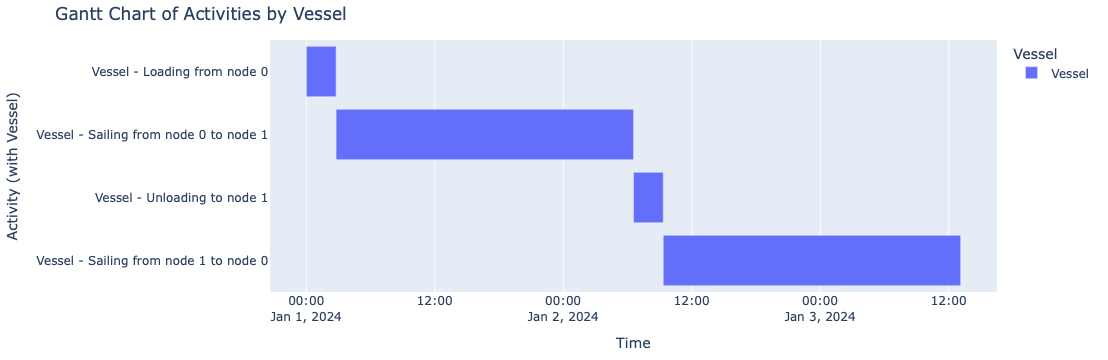

In [17]:
# create a Gantt chart from the eventtable

# add vessel name to activity label
eventtable['activity label'] = eventtable['object name'] + ' - ' + eventtable['activity name']

# create the Gantt chart
fig = px.timeline(
    eventtable,
    x_start="start time",
    x_end="stop time",
    y="activity label",
    color="object name",
    title="Gantt Chart of Activities by Vessel"
)

# reverse the Y-axis to match Gantt chart style
fig.update_yaxes(autorange="reversed")

# customize layout
fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Activity (with Vessel)",
    legend_title="Vessel",
    margin=dict(l=20, r=20, t=40, b=20)
)

# show the chart
fig.show()